In [5]:
!pip install mlflow
!pip install pyarrow==14.0.2
!pip install datasets==2.16.1 mlflow==2.9.2 scikit-learn pandas numpy
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 180.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 206.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers] [transformers]


2026/03/09 07:54:06 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


                                                text  label
0  Closet organizer install complete.  Now for th...      0
1  Mornin' All!!  ....I need to wake up....this w...      1
2  @Lega_c ahhhhhhhhhh! he suxxxxxxx! he claimed ...      0
3  @endlessblush Haha. I guess all the good bits ...      0
4                                  family guy funny       1


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Running HuggingFace predictions...


100%|██████████| 20000/20000 [10:40<00:00, 31.23it/s]
2026/03/09 08:04:47 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 08:04:47 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 08:04:47 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 08:04:47 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 08:04:47 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09 08:04:47 WARNING mlflow.tracking.request_header.registry: Encountered unexpected error during resolving request headers: list index out of range
2026/03/09


Ejecución Exitosa
Experimento: Parcial_NLP (ID: 8)
F1 Score final: 0.7086

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.81      0.74     10070
           1       0.76      0.62      0.68      9930

    accuracy                           0.71     20000
   macro avg       0.72      0.71      0.71     20000
weighted avg       0.72      0.71      0.71     20000

🏃 View run HuggingFace_RawText at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8/runs/3d6a543fdd244c8abb44e0f7eec412b9
🧪 View experiment at: http://ec2-54-174-164-37.compute-1.amazonaws.com:5000/#/experiments/8


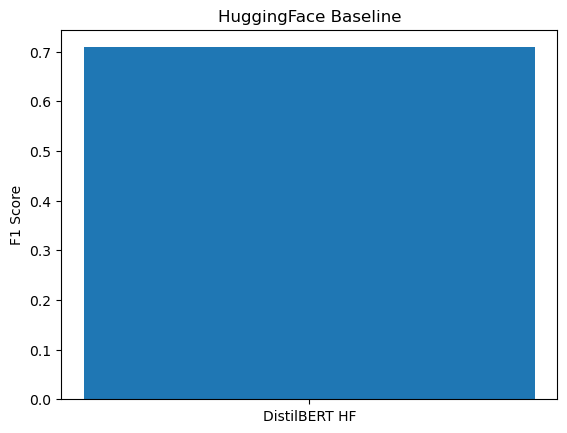

In [9]:
import numpy as np
import pandas as pd
import mlflow
import os
import time
import json
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import f1_score, classification_report
from transformers import pipeline
from tqdm import tqdm


# CONFIGURACIÓN MLFLOW

mlflow.set_tracking_uri("http://ec2-54-174-164-37.compute-1.amazonaws.com:5000")

experiment_name = "Parcial_NLP"

try:
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        experiment_id = mlflow.create_experiment(experiment_name)
    else:
        experiment_id = exp.experiment_id
except Exception as e:
    print(f"Error al conectar con MLflow: {e}")
    experiment_id = "0"


# CARPETAS

os.makedirs("outputs/model", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)
os.makedirs("data", exist_ok=True)


# CARGAR DATASET

dataset = load_dataset("adilbekovich/Sentiment140Twitter")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.head())


# USAR TEXTO EN CRUDO (RAW)

X_test_text = test_df["text"]
y_test = test_df["label"]


# LIMITAR PARA QUE NO TARDE HORAS

sample_size = 20000

X_test_text = X_test_text.sample(sample_size, random_state=42)
y_test = y_test.loc[X_test_text.index]


# PIPELINE HUGGINGFACE

classifier = pipeline("sentiment-analysis")


# PREDICCIONES

start_time = time.time()

predictions = []

print("\nRunning HuggingFace predictions...")

for text in tqdm(X_test_text):

    result = classifier(text)[0]

    label = result["label"]

    if label == "POSITIVE":
        predictions.append(1)
    else:
        predictions.append(0)

y_pred = np.array(predictions)


# MÉTRICA

f1 = f1_score(y_test, y_pred, average="weighted")

execution_time = time.time() - start_time


# MLFLOW

with mlflow.start_run(experiment_id=experiment_id, run_name="HuggingFace_RawText"):

    mlflow.log_params({
        "model": "distilbert-base-uncased",
        "library": "HuggingFace Transformers",
        "dataset": "Sentiment140",
        "input_type": "raw_text",
        "sample_size": sample_size
    })

    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("runtime_seconds", execution_time)


    # TAGS

    mlflow.set_tag("dataset", "Sentiment140")
    mlflow.set_tag("feature_type", "Raw Text")
    mlflow.set_tag("model_type", "DistilBERT")
    mlflow.set_tag("evaluation_metric", "f1_score")
    mlflow.set_tag("experiment_stage", "baseline_huggingface")
    mlflow.set_tag("author", "Nicolas")


    # MODEL CARD

    model_card = {
        "model_name": "HuggingFace DistilBERT Sentiment",
        "input": "raw tweets",
        "dataset": "Sentiment140",
        "f1_score": float(f1),
        "author": "Nicolas"
    }

    with open("outputs/model/model_card_hf.json", "w") as f:
        json.dump(model_card, f, indent=4)


    # RESULTADOS

    baseline_df = pd.DataFrame([{
        "model": "DistilBERT",
        "input": "Raw Text",
        "f1_score": f1,
        "author": "Nicolas"
    }])

    baseline_df.to_csv("outputs/reports/baseline_results_hf.csv", index=False)


    # PLOT

    plt.figure()
    plt.bar(["DistilBERT HF"], [f1])
    plt.ylabel("F1 Score")
    plt.title("HuggingFace Baseline")
    plt.savefig("outputs/reports/baseline_plot_hf.png")


    mlflow.log_artifact("outputs/model/model_card_hf.json")
    mlflow.log_artifact("outputs/reports/baseline_results_hf.csv")
    mlflow.log_artifact("outputs/reports/baseline_plot_hf.png")


    print("\nEjecución Exitosa")
    print(f"Experimento: {experiment_name} (ID: {experiment_id})")
    print(f"F1 Score final: {f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))